In [1]:
import os
import sys
import numpy
import pandas
pandas.options.mode.chained_assignment = None  # default='warn'
from datetime import datetime, timedelta
import pytz
import shapely
from shapely import wkb, wkt
import geopandas
import dask_geopandas
import pystac_client

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Access credentials

In [2]:
import dotenv
dotenv.load_dotenv()

# S3 access key
access_key_id = os.getenv('access_key_id', '')
# S3 access secret
secret_access_key = os.getenv('secret_access_key', '')
# S3 access url
endpoint_url = os.getenv('endpoint_url', '')
# S3 bucket
bucket = os.getenv('bucket', '')

# STAC query for filtering assets

In [3]:
# Platform configuration
ISO_8601 = '%Y-%m-%dT%H:%M:%SZ'

# STAC service URL
STAC_URL="https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com"

# STAC catalogue
catalog = pystac_client.Client.open(STAC_URL)
collections = catalog.get_all_collections()
cl_id = [c.id for c in collections]
for c in cl_id:
    print(f"collection: {c}")

collection: esa-sentinel-2A-msil1c
collection: HLSS30
collection: global-weather-era5
collection: dev_ne_10m_admin_0_countries
collection: gedi-l2a
collection: atmospheric-era5
collection: test-gedi-l2a
collection: atmospheric-weather-era5
collection: ds335-sentinel1
collection: sentinel-1-grd
collection: dev_kaggle_wildfire
collection: ibm-eis-ga-1-esa-sentinel-2-l2a
collection: Radar
collection: Radar-10min
collection: tasmax-rcp85-land-cpm-uk-2.2km
collection: ibm-eis-ga-1-era5-pr-wdc
collection: HLSL30_version2
collection: vector-osm-power
collection: vector-osm-building
collection: vector-osm-poi
collection: vector-osm-road
collection: vector-osm-natural
collection: vector-osm-railway
collection: vector-osm-boundary
collection: vector-osm-landuse
collection: vector-osm-waterway
collection: dev-hsi-radar-10min


In [4]:
# Collection
collection_id = 'vector-osm-building'

In [5]:
# Stac collection
collection = catalog.get_collection(collection_id)

# Get the names of the temporal and geometry columns from the collection
cube_dimensions = collection.extra_fields['cube:dimensions']
dt_col = [k for k in cube_dimensions if cube_dimensions[k]['type']=='temporal']
assert len(dt_col)==1 # Currently supporting just one temporal dimension
dt_col = dt_col[0]
geom_col = 'geometry' # Currently supporting just one geometry column called 'geometry'
collection

<CollectionClient id=vector-osm-building>

query bounds:   (35.8219, -2.2921, 37.9219, -0.19210000000000002)
time_range:     1970-01-01T00:00:00Z/2029-12-31T23:59:59Z



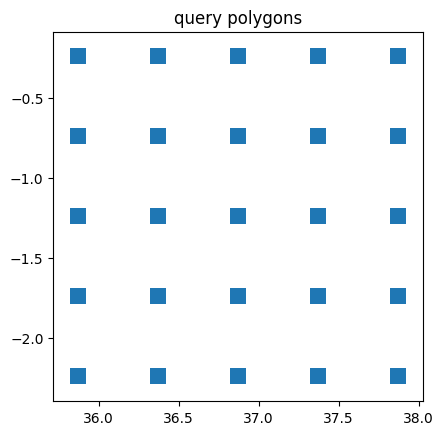

In [6]:
# construct a rectangular mesh
# Example query areas centered at Nairobi Kenya
points = []
for x in numpy.arange(36.8219-1, 36.8219+1.1, 0.5):
    for y in numpy.arange(-1.2921-1, -1.2921+1.1, 0.5):
        points.append(shapely.Point(x, y))
single_box = shapely.box(0, 0, .1, .1)
query_polygons = [shapely.affinity.translate(single_box, xoff=p.x, yoff=p.y) for p in points]
query_multipolygon = shapely.MultiPolygon(query_polygons)
df_query = pandas.DataFrame({'geometry': query_polygons})
gdf_query = geopandas.GeoDataFrame(df_query)
ddf_query = dask_geopandas.from_geopandas(gdf_query, npartitions=1)

dt_start = datetime(1970, 1, 1, tzinfo=pytz.utc)
dt_end = datetime(2030, 1, 1, tzinfo=pytz.utc)-timedelta(seconds=1)

# Temporal query range
start = dt_start.strftime(ISO_8601)
end = dt_end.strftime(ISO_8601)
# STAC notation
time_range = f"{start}/{end}"

print(f"query bounds:   {query_multipolygon.bounds}")
print(f"time_range:     {time_range}")
print()
gdf_query.plot()
plt.title('query polygons')
plt.show()

In [7]:
# Search the Stac catalog collection for matching items
limit=10000
search = catalog.search(collections=[collection_id], intersects=query_multipolygon, datetime=time_range, limit=limit)
items = search.item_collection().items
assert len(items)<limit

gdf_items = geopandas.GeoDataFrame.from_features(items)
hrefs = [item.assets['data'].href for item in items]
gdf_items['href'] = hrefs
print(f"items found: {len(items)}")

gdf_items.tail(2)

items found: 6


,geometry,proj:epsg,end_datetime,cube:variables,start_datetime,cube:dimensions,datetime,href
4,"POLYGON ((36.74462 -1.40625, 36.60097 -1.40471...",4326,2024-05-19T19:51:29Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2008-09-11T10:15:55Z,"{'geometry': {'bbox': [36.562501, -1.4062482, ...",None,s3://fm-geospatial-cos-dev/vectorstore/osm_bui...
5,"POLYGON ((77.11620 -80.41724, 77.11326 -80.417...",4326,2024-05-19T19:46:12Z,"{'ref': {'type': 'data', 'unit': '', 'dimensio...",2008-05-27T00:44:52Z,"{'geometry': {'bbox': [0.023155, -80.4172399, ...",None,s3://fm-geospatial-cos-dev/vectorstore/osm_bui...


# Query remote data using dask_geopandas

## Standard Query using "intersects" logic

In [8]:
%%time
filters = []
filters.append((dt_col, '>=', dt_start))
filters.append((dt_col, '<=', dt_end))

ddf = dask_geopandas.read_parquet(
    hrefs,
    storage_options={
        'key' : access_key_id,
        'secret' : secret_access_key,
        'client_kwargs' : {'endpoint_url': endpoint_url},
    },
    # columns=['name', 'building', dt_col, geom_col, '_root'],
    filters=filters,
)
ddf

CPU times: total: 46.9 ms
Wall time: 5.11 s


,address,admin_level,aerialway,aeroway,amenity,barrier,boundary,building,craft,emergency,geological,geometry,highway,historic,is_in,land_area,landuse,leisure,man_made,military,name,name:en,natural,office,osm_id,osm_node_id,osm_relation_id,osm_timestamp,osm_version,osm_way_id,other_tags,place,power,public_transport,pyogrio_layer,railway,ref,route,shop,sport,tourism,type,waterway,z_order,_root,grid,spatial_partition
npartitions=6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,object,object,object,object,object,object,object,object,object,object,object,geometry,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,"datetime64[ns, UTC]",int32,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,object,category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [9]:
# Use dask_geopandas to process multiple polygon queries in parallel
def overlay(left, right):
    """mimic geopandas overlay.
    
    https://github.com/geopandas/dask-geopandas/issues/236
    """
    return (
        left.sjoin(right.assign(right_geometry=right.geometry))
        .assign(geometry=lambda x: x.geometry.intersection(x.right_geometry))
        .drop(columns="right_geometry")
    )

ddf_overlay = overlay(ddf, ddf_query)
ddf_overlay

,address,admin_level,aerialway,aeroway,amenity,barrier,boundary,building,craft,emergency,geological,geometry,highway,historic,is_in,land_area,landuse,leisure,man_made,military,name,name:en,natural,office,osm_id,osm_node_id,osm_relation_id,osm_timestamp,osm_version,osm_way_id,other_tags,place,power,public_transport,pyogrio_layer,railway,ref,route,shop,sport,tourism,type,waterway,z_order,_root,grid,spatial_partition,index_right
npartitions=6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,string,string,string,string,string,string,string,string,string,geometry,string,string,string,string,string,string,string,string,string,string,string,string,string,string,string,"datetime64[ns, UTC]",int32,string,string,string,string,string,string,string,string,string,string,string,string,string,string,float64,string,category[known],category[known],int64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [10]:
%%time
gdf_overlay = ddf_overlay.compute()

CPU times: total: 18.1 s
Wall time: 1min


In [11]:
%%time
# Split the results into multiple GeoDataFrames as indicated in "index_right"
gdfs = dict(tuple(gdf_overlay.groupby('index_right')))

CPU times: total: 78.1 ms
Wall time: 124 ms


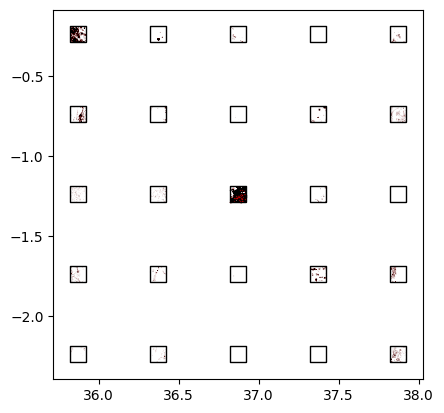

In [12]:
ax = gdf_overlay.sample(frac=1).plot(color='red', edgecolor='k', alpha=.5, lw=.2, markersize=1) #, figsize=(20,20))
geopandas.GeoDataFrame([{'geometry': query_multipolygon}]).plot(ax=ax, color='none', edgecolor='k')
plt.show()

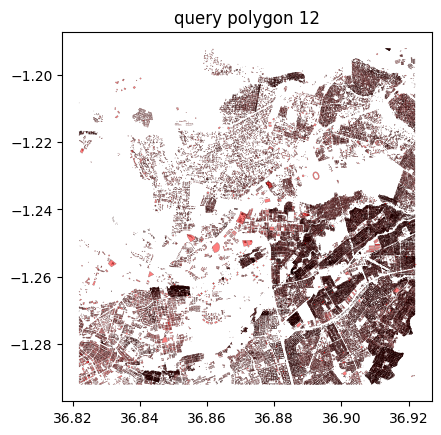

In [13]:
query_n = 12
gdfs[query_n].sample(frac=1).plot(color='red', edgecolor='k', alpha=.5, lw=.2, markersize=1) #, figsize=(20,20))
plt.title(f"query polygon {query_n}")
plt.show()